In [46]:
import os
import json
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Concatenate, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix


In [47]:
def advanced_preprocessing(image_path, target_size=(224, 224)):
    """Apply preprocessing to images including resizing, Gaussian blur, and histogram equalization."""
    img = cv2.imread(image_path)  # Read image
    if img is None:
        return None
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, target_size)  # Resize
    
    # Apply Gaussian Blur
    img = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Convert to grayscale for histogram equalization
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    equalized = cv2.equalizeHist(gray)
    
    # Normalize and apply thresholding
    _, thresholded = cv2.threshold(equalized, 128, 255, cv2.THRESH_BINARY)
    
    # Convert back to 3 channels
    processed_img = cv2.merge([thresholded, thresholded, thresholded])
    
    return processed_img / 255.0  # Normalize


In [48]:
def load_dataset(photos_dir, labels_file, limit=500):
    """Load dataset including images and captions."""
    images, labels, captions = [], [], []
    
    with open(labels_file, "r") as f:
        lines = [json.loads(line.strip()) for line in f.readlines()[:limit]]
    
    for entry in tqdm(lines, desc="Processing Images"):
        photo_id = entry["photo_id"]
        label = entry["label"]
        caption = entry["caption"]
        image_path = os.path.join(photos_dir, f"{photo_id}.jpg")
        
        if os.path.exists(image_path):
            processed_img = advanced_preprocessing(image_path)
            if processed_img is not None:
                images.append(processed_img)
                labels.append(label)
                captions.append(caption)
    
    return np.array(images), np.array(labels), captions


In [49]:
def preprocess_captions(captions, max_words=10000, max_length=20):
    """Tokenize and pad captions."""
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(captions)
    sequences = tokenizer.texts_to_sequences(captions)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')
    
    return padded_sequences, tokenizer


In [50]:
def encode_labels(labels, classes):
    """Convert labels into categorical format."""
    label_to_index = {label: idx for idx, label in enumerate(classes)}
    encoded_labels = [label_to_index[label] for label in labels]
    return to_categorical(encoded_labels, num_classes=len(classes))


In [51]:
# Define paths
photos_dir = "/mnt/c/users/sarak/Sem3/Yelp-Photos/photos"  # Update this path
labels_file = "/mnt/c/users/sarak/Sem3/Yelp-Photos/photos.json"  # Update this path

# Define class names
classes = ['drink', 'food', 'inside', 'menu', 'outside']

# Load dataset
images, labels, captions = load_dataset(photos_dir, labels_file)

# Process captions
padded_captions, tokenizer = preprocess_captions(captions)

# Encode labels
encoded_labels = encode_labels(labels, classes)

# Train-test split
X_img_train, X_img_test, X_cap_train, X_cap_test, y_train, y_test = train_test_split(
    images, padded_captions, encoded_labels, test_size=0.2, random_state=42
)


Processing Images: 100%|██████████| 500/500 [00:14<00:00, 35.29it/s]


In [52]:
# Load VGG16 model without top layers
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze layers initially


In [53]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Image feature extractor
image_input = Input(shape=(224, 224, 3), name="image_input")
x = base_model(image_input, training=False)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Text feature extractor
caption_input = Input(shape=(X_cap_train.shape[1],), name="caption_input")
caption_embedding = Dense(256, activation="relu")(caption_input)

# Concatenate both branches
combined = Concatenate()([x, caption_embedding])
output = Dense(len(classes), activation="softmax")(combined)

# Define model
model = Model(inputs=[image_input, caption_input], outputs=output)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

In [54]:
# Train model
history = model.fit(
    {"image_input": X_img_train, "caption_input": X_cap_train},
    y_train,
    validation_data=({"image_input": X_img_test, "caption_input": X_cap_test}, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.3447 - loss: 19.4702

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 503ms/step - accuracy: 0.3482 - loss: 19.3383 - val_accuracy: 0.4000 - val_loss: 15.0754
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4586 - loss: 11.1288

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4600 - loss: 11.0864 - val_accuracy: 0.4400 - val_loss: 10.4916
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5467 - loss: 7.9342

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 449ms/step - accuracy: 0.5476 - loss: 7.8913 - val_accuracy: 0.5800 - val_loss: 7.9124
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6303 - loss: 5.8709

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.6297 - loss: 5.8236 - val_accuracy: 0.5600 - val_loss: 6.9806
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6610 - loss: 4.0283

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.7144 - loss: 3.3740 - val_accuracy: 0.6100 - val_loss: 6.0807
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7426 - loss: 2.8667

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.7431 - loss: 2.8746 - val_accuracy: 0.6400 - val_loss: 5.7802
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7626 - loss: 2.0968

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.7616 - loss: 2.1289 - val_accuracy: 0.6200 - val_loss: 5.6325
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8124 - loss: 2.1113 

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.8113 - loss: 2.1142 - val_accuracy: 0.6600 - val_loss: 5.3995
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8037 - loss: 2.3625

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8038 - loss: 2.3265 - val_accuracy: 0.6700 - val_loss: 5.2629


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step
              precision    recall  f1-score   support

       drink       0.00      0.00      0.00         8
        food       0.70      0.82      0.75        49
      inside       0.68      0.74      0.71        35
        menu       1.00      0.33      0.50         3
     outside       0.00      0.00      0.00         5

    accuracy                           0.67       100
   macro avg       0.48      0.38      0.39       100
weighted avg       0.61      0.67      0.63       100

AUC Score: 0.7651


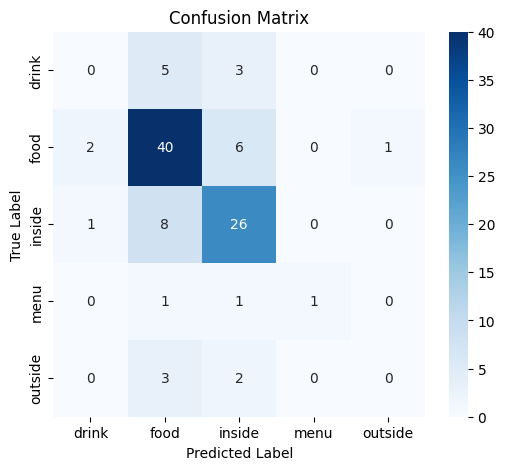

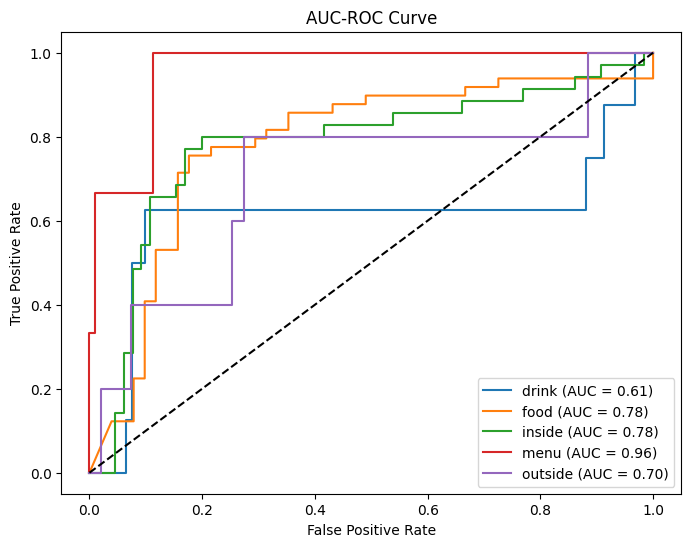

In [55]:
y_pred = model.predict({"image_input": X_img_test, "caption_input": X_cap_test})
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# Compute AUC Score
auc_score = roc_auc_score(y_test, y_pred, multi_class="ovr")
print(f"AUC Score: {auc_score:.4f}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Plot AUC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])  # Get FPR & TPR
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [56]:
print("X_img_train shape:", X_img_train.shape)
print("X_cap_train shape:", X_cap_train.shape)
print("y_train shape:", y_train.shape)

print("X_img_test shape:", X_img_test.shape)
print("X_cap_test shape:", X_cap_test.shape)
print("y_test shape:", y_test.shape)


X_img_train shape: (399, 224, 224, 3)
X_cap_train shape: (399, 20)
y_train shape: (399, 5)
X_img_test shape: (100, 224, 224, 3)
X_cap_test shape: (100, 20)
y_test shape: (100, 5)


## Fine Tuning the model

Applying Class Weights

In [57]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_true_classes),
    y=y_true_classes
)

# Convert to dictionary format
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}


In [58]:
print(class_weight_dict)

{0: np.float64(2.5), 1: np.float64(0.40816326530612246), 2: np.float64(0.5714285714285714), 3: np.float64(6.666666666666667), 4: np.float64(4.0)}


In [59]:

# Retrain model with class weights
history = model.fit(
    {"image_input": X_img_train, "caption_input": X_cap_train},
    y_train,
    validation_data=({"image_input": X_img_test, "caption_input": X_cap_test},y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict
)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.7812 - loss: 3.5264 - val_accuracy: 0.5400 - val_loss: 5.6576
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7388 - loss: 1.8026 - val_accuracy: 0.6300 - val_loss: 5.3652
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.8269 - loss: 1.5018 - val_accuracy: 0.6600 - val_loss: 5.0360
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.8211 - loss: 1.1253 - val_accuracy: 0.6500 - val_loss: 4.9321
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8562 - loss: 0.8231 - val_accuracy: 0.6300 - val_loss: 4.8171
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.8528 - loss: 0.9514 - val_accuracy: 0.6500 - val_loss: 4.7558
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.9129 - loss: 0.6664 - val_accuracy: 0.6800 - val_loss: 4.5765
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8645 - loss: 1.1543 - val_accuracy: 0.650

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
              precision    recall  f1-score   support

       drink       0.30      0.38      0.33         8
        food       0.81      0.80      0.80        49
      inside       0.76      0.63      0.69        35
        menu       0.33      0.33      0.33         3
     outside       0.20      0.40      0.27         5

    accuracy                           0.67       100
   macro avg       0.48      0.51      0.48       100
weighted avg       0.71      0.67      0.68       100

AUC Score: 0.7736


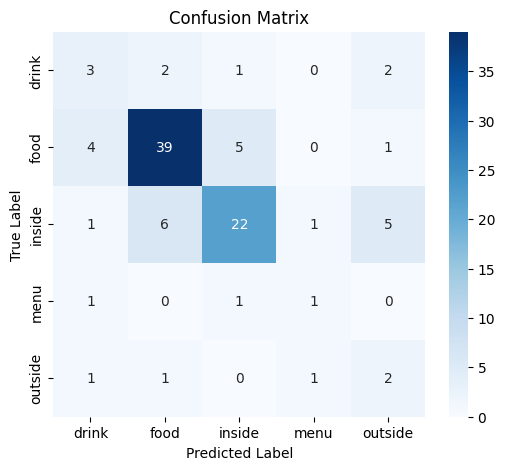

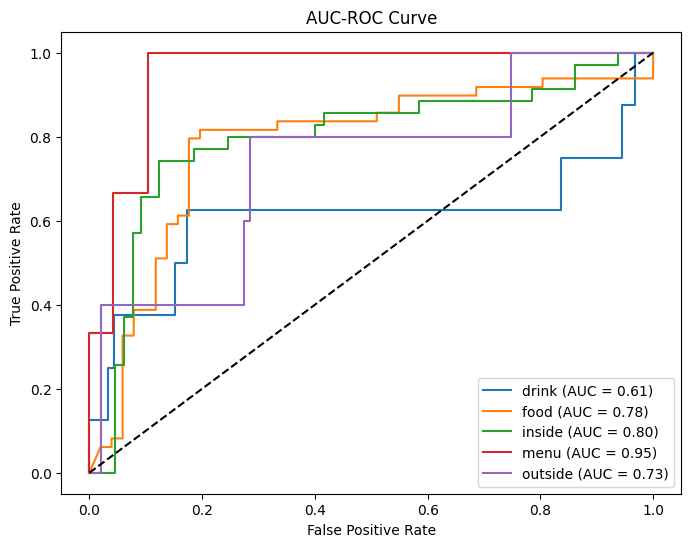

In [60]:
y_pred = model.predict({"image_input": X_img_test, "caption_input": X_cap_test})
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# Compute AUC Score
auc_score = roc_auc_score(y_test, y_pred, multi_class="ovr")
print(f"AUC Score: {auc_score:.4f}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Plot AUC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])  # Get FPR & TPR
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend(loc="lower right")
plt.show()


Unfreezing last few layers and retraining the model

In [75]:
# Unfreeze last few layers of VGG16
for layer in base_model.layers[-10:]:  
    layer.trainable = True  

# Compile model with lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Retrain
history = model.fit(
    {"image_input": X_img_train, "caption_input": X_cap_train},
    y_train,
    validation_data=({"image_input": X_img_test, "caption_input": X_cap_test},y_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10
11/13 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step - accuracy: 0.9263 - loss: 0.4949

2025-02-10 12:58:55.739797: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-02-10 12:58:56.511246: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.21GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-02-10 12:58:58.448246: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.12GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-02-10 12:58:59.397945: W external/local_xla/xla/ts

13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 974ms/step - accuracy: 0.9245 - loss: 0.5052 - val_accuracy: 0.7200 - val_loss: 4.3121
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.9302 - loss: 0.3882 - val_accuracy: 0.7300 - val_loss: 4.1259
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.9609 - loss: 0.1313 - val_accuracy: 0.7300 - val_loss: 4.0870
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.9636 - loss: 0.2352 - val_accuracy: 0.7300 - val_loss: 4.1519
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.9699 - loss: 0.0865 - val_accuracy: 0.7100 - val_loss: 4.0876
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.9731 - loss: 0.1087 - val_accuracy: 0.7100 - val_loss: 4.0679
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.9892 - loss: 0.0779 - val_accuracy: 0.7500 - val_loss: 4.2060
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.9801 - loss: 0.1252 - val_accuracy: 0.7300 - val

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step
              precision    recall  f1-score   support

       drink       0.40      0.25      0.31         8
        food       0.77      0.84      0.80        49
      inside       0.75      0.69      0.72        35
        menu       1.00      0.33      0.50         3
     outside       0.22      0.40      0.29         5

    accuracy                           0.70       100
   macro avg       0.63      0.50      0.52       100
weighted avg       0.71      0.70      0.70       100

AUC Score: 0.8157


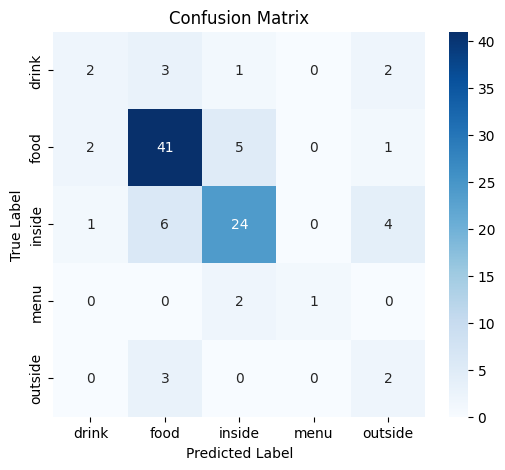

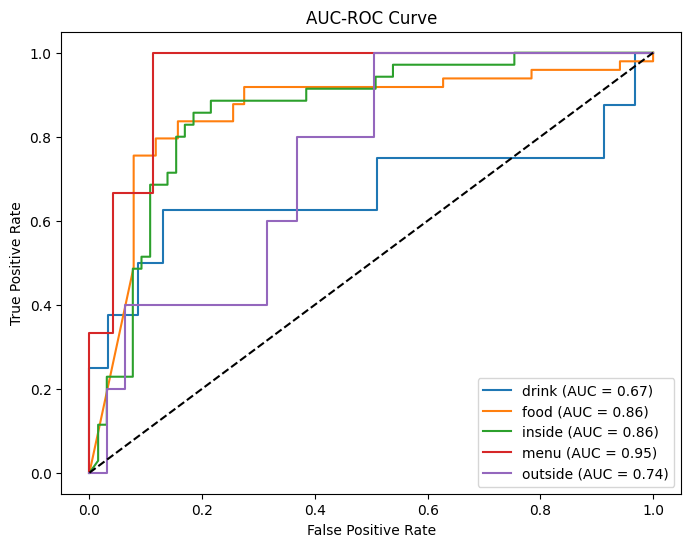

In [76]:
y_pred = model.predict({"image_input": X_img_test, "caption_input": X_cap_test})
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# Compute AUC Score
auc_score = roc_auc_score(y_test, y_pred, multi_class="ovr")
print(f"AUC Score: {auc_score:.4f}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Plot AUC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])  # Get FPR & TPR
    roc_auc = auc(fpr, tpr)  # Compute AUC
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend(loc="lower right")
plt.show()
